In [1]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import ResNet50
tf.keras.backend.clear_session()
import gc
gc.collect()

import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
from dotenv import load_dotenv

"""
1) Buscar as máscaras - OK
2) Carregar e pré-processar as máscaras - OK
3) Criar pipeline para Aumento de Dados - OK
4) Configurar um dataset baseado nas máscaras - OK
5) Formular um treinamento - PENDENTE
6) Visualizar imagens - OK
"""

### 1. Configurar o caminho e criar lista de imagens ###
load_dotenv()

img_dir = os.getenv("BASE_IMG_FOLDER")
img_dir = pathlib.Path(img_dir)
mask_dir = os.getenv("NUMPY_FOLDER")
mask_dir = pathlib.Path(mask_dir)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))
def get_file_number_mask(filepath):
    return int(os.path.basename(filepath).replace('.npy', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.npy'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number_mask)

if len(image_files) != len(mask_files):
    raise ValueError("O número de imagens e máscaras não corresponde")

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)



2025-03-19 13:26:00.621873: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 13:26:00.646827: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-19 13:26:00.646894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-19 13:26:00.647710: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-19 13:26:00.652845: I tensorflow/core/platform/cpu_feature_guar

Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/santiago/HD710PRO/ImagenesSinteticas/output/000.npy
/media/santiago/HD710PRO/ImagenesSinteticas/output/001.npy
/media/santiago/HD710PRO/ImagenesSinteticas/output/002.npy
/media/santiago/HD710PRO/ImagenesSinteticas/output/003.npy
/media/santiago/HD710PRO/ImagenesSinteticas/output/004.npy


In [2]:
import numpy as np
# Linux
mask = np.load(r'/media/santiago/HD710PRO/ImagenesSinteticas/output/000.npy')
# Windows
# mask = np.load('C:\\Users\\Renato\\Documents\\PIBIC\\NumpyFiles\\000.npy')

In [3]:
mask.shape

(512, 512, 22)

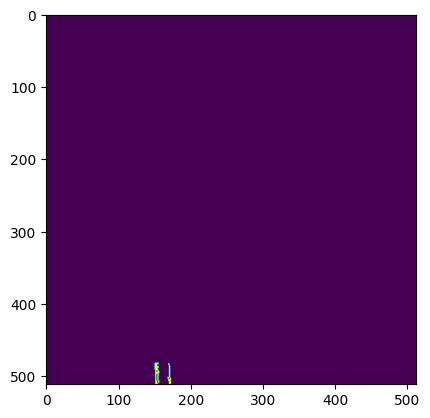

In [4]:
plt.imshow(mask[:,:,3])

In [6]:
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Carregar imagem RGB
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [512, 512])  # Redimensionar o tamanho
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar a imagem

        # Carregar máscara do arquivo numpy
        mask = np.load(mask_path.numpy().decode())  # Ler a máscara
        mask = tf.convert_to_tensor(mask, dtype=tf.float32)  # Converter como tensor

        # Normalizar máscara
        mask = mask / 255.0  # Converter valores de 0-255 a 0-1
        mask = tf.where(mask >= 0.3, 1.0, 0.0)  # Binarizar a máscara

        return img, mask
    except Exception as e:
        print(f"Erro ao processar imagem/máscara {image_path}, {mask_path}: {str(e)}")
        raise


## Função para aplicar aumento de dados considerando máscaras como arrays multicamadas
def augment_image_mask(image, mask):
    # Gere um valor aleatório comum para transformações
    flip_left_right = tf.random.uniform(shape=[]) > 0.5
    flip_up_down = tf.random.uniform(shape=[]) > 0.5
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)  # 0, 90, 180, 270 graus

    # Flip horizontal
    if flip_left_right:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip vertical
    if flip_up_down:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Aplicar rotação à imagem
    image = tf.image.rot90(image, k=k)

    # Aplique rotação à máscara em toda a sua dimensão
    mask = tf.image.rot90(mask, k=k)  # Agora giramos a máscara inteira de uma vez

    # Configurações adicionais de imagem
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, mask

# Converter listas de rotas em conjunto de dados do TensorFlow
def process_path(image_path, mask_path):
    img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
    img.set_shape((512, 512, 3))  # Defina o tamanho esperado da imagem
    mask.set_shape((512, 512, 22))  # Defina o tamanho esperado da máscara
    return img, mask

# Criar um conjunto de dados a partir de listas de imagens e máscaras
train_dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
train_dataset = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar Aumento de Dados
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Configurar o conjunto de dados
BUFFER_SIZE = 100   # Talvez aumentar para 128 no futuro
BATCH_SIZE = 8     # Talvez aumentar para 64 no futuro

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspecionar o conjunto de dados
for img, mask in train_dataset.take(1):
    print(f"Imagem em lote: {img.shape}")  # Esperado: (batch_size, 256, 256, 3)
    print(f"Máscara em lote: {mask.shape}")  # Esperado: (batch_size, 256, 256, 18)

Imagem em lote: (8, 512, 512, 3)
Máscara em lote: (8, 512, 512, 22)


In [7]:
mask[0]

<tf.Tensor: shape=(512, 512, 22), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0.

In [8]:


def deeplabv3plus(input_shape=(512, 512, 3), num_classes=22):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Encoder (Backbone)
    layer_names = [
        'conv1_relu',   # Baja resolución
        'conv2_block3_out',
        'conv3_block4_out',
        'conv4_block6_out'  # Alta resolución
    ]
    layers = [base_model.get_layer(name).output for name in layer_names]
    encoder = tf.keras.Model(inputs=base_model.input, outputs=layers)

    # ASPP Module
    def aspp(x):
        shape = tf.keras.backend.int_shape(x)[1:3]
        
        x1 = tf.keras.layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
        x1 = tf.keras.layers.BatchNormalization()(x1)
        x1 = tf.keras.layers.ReLU()(x1)

        x2 = tf.keras.layers.Conv2D(256, 3, padding="same", dilation_rate=6, use_bias=False)(x)
        x2 = tf.keras.layers.BatchNormalization()(x2)
        x2 = tf.keras.layers.ReLU()(x2)

        x3 = tf.keras.layers.Conv2D(256, 3, padding="same", dilation_rate=12, use_bias=False)(x)
        x3 = tf.keras.layers.BatchNormalization()(x3)
        x3 = tf.keras.layers.ReLU()(x3)

        x4 = tf.keras.layers.Conv2D(256, 3, padding="same", dilation_rate=18, use_bias=False)(x)
        x4 = tf.keras.layers.BatchNormalization()(x4)
        x4 = tf.keras.layers.ReLU()(x4)

        x5 = tf.keras.layers.GlobalAveragePooling2D()(x)
        x5 = tf.keras.layers.Reshape((1, 1, x5.shape[-1]))(x5)
        x5 = tf.keras.layers.Conv2D(256, 1, use_bias=False)(x5)
        x5 = tf.keras.layers.BatchNormalization()(x5)
        x5 = tf.keras.layers.ReLU()(x5)
        x5 = tf.keras.layers.UpSampling2D(size=(shape[0], shape[1]), interpolation="bilinear")(x5)

        return tf.keras.layers.Concatenate()([x1, x2, x3, x4, x5])

    inputs = tf.keras.Input(shape=input_shape)
    features = encoder(inputs)[-1]
    x = aspp(features)
    x = tf.keras.layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)

    # Decoder
    low_level_features = encoder(inputs)[1]
    low_level_features = tf.keras.layers.Conv2D(48, 1, padding="same", use_bias=False)(low_level_features)
    low_level_features = tf.keras.layers.BatchNormalization()(low_level_features)
    low_level_features = tf.keras.layers.ReLU()(low_level_features)
    x = tf.keras.layers.Concatenate()([x, low_level_features])
    x = tf.keras.layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x) 

    # Capa final explícitamente en float32 (¡importante!)
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation="sigmoid", dtype='float32')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Crear y resumir el modelo
model = deeplabv3plus()
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 model (Functional)          [(None, 256, 256, 64),       8589184   ['input_2[0][0]',             
                              (None, 128, 128, 256),                 'input_2[0][0]']             
                              (None, 64, 64, 512),                                                
                              (None, 32, 32, 1024)]                                               
                                                                                                  
 global_average_pooling2d (  (None, 1024)                 0         ['model[0][3]']         

In [9]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_pred = tf.keras.backend.clip(y_pred, 1e-7, 1 - 1e-7)
        focal_loss = -alpha * y_true * tf.keras.backend.pow(1 - y_pred, gamma) * tf.keras.backend.log(y_pred)
        focal_loss -= (1 - alpha) * (1 - y_true) * tf.keras.backend.pow(y_pred, gamma) * tf.keras.backend.log(1 - y_pred)
        return tf.keras.backend.mean(focal_loss)
    return loss

In [10]:
for img, mask in train_dataset.take(1):
    print(f"Formato da máscara: {mask.shape}")  # Deve ser (256, 256, 22)
    print(f"Tipo de dados da máscara: {mask.dtype}")  # Deve ser float32
    #print(f"Valores únicos na máscara: {tf.unique(tf.reshape(mask, [-1]))[0].numpy()}")  # Deve conter valores entre 0 a 1

Formato da máscara: (8, 512, 512, 22)
Tipo de dados da máscara: <dtype: 'float32'>


In [11]:
## Obter o número total de amostras no conjunto de dados sem lote prévio
dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
dataset_size = tf.data.experimental.cardinality(dataset).numpy()

# Definir proporções para treinar, validar e testar
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

# Mesclar o conjunto de dados antes de dividir
shuffled_dataset = dataset.shuffle(BUFFER_SIZE)
shuffled_dataset = shuffled_dataset.shuffle(BUFFER_SIZE)

# Divida o conjunto de dados ANTES de aplicar o lote para evitar o problema de lote duplo
train_dataset = shuffled_dataset.take(train_size)
remaining_dataset = shuffled_dataset.skip(train_size)
val_dataset = remaining_dataset.take(val_size)
test_dataset = remaining_dataset.skip(val_size)

# Aplicar aumento de dados apenas ao conjunto de treinamento
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar lote após divisão
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Confirmar os tamanhos do conjunto
print(f'Tamanho do conjunto de dados de treinamento: {train_size}')
print(f'Tamanho do conjunto de dados de validação: {val_size}')
print(f'Tamanho do conjunto de dados de avaliação: {test_size}')

Tamanho do conjunto de dados de treinamento: 4028
Tamanho do conjunto de dados de validação: 503
Tamanho do conjunto de dados de avaliação: 505


In [12]:
for img, mask in train_dataset.take(1):
    print(f"Formato da imagem (lote): {img.shape}")  # Deve ser (BATCH_SIZE, 256, 256, 3)
    print(f"Formato da máscara (lote): {mask.shape}")  # Deve ser (BATCH_SIZE, 256, 256, 22)

Formato da imagem (lote): (8, 512, 512, 3)
Formato da máscara (lote): (8, 512, 512, 22)


In [13]:
# Callbacks para mejorar el entrenamiento
callbacks = [
    # Early stopping para prevenir el sobreajuste
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # Permitir más épocas antes de detenerse si no hay mejora
        restore_best_weights=True,
        verbose=1
    ),

    # Guardar el mejor modelo basado en la menor pérdida de validación
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_focal.keras',
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    ),

    # Reducir la tasa de aprendizaje si la pérdida de validación se estanca
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # Reducir la tasa de aprendizaje a la mitad si no hay mejora
        patience=5,  # Esperar 5 épocas sin mejora antes de reducir
        min_lr=1e-6,  # Límite inferior para la tasa de aprendizaje
        verbose=1
    ),

    # Registrar métricas en TensorBoard
    tf.keras.callbacks.TensorBoard(
        log_dir='logs_focal',
        histogram_freq=1,
        write_graph=True,
        write_images=True
    )
]

# Tasa de aprendizaje inicial y programador de decaimiento exponencial
initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True
)

# Compilar el modelo con focal loss y métricas específicas
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=focal_loss(),
    metrics=['accuracy', 
             tf.keras.metrics.MeanIoU(num_classes=22),
             tf.keras.metrics.Precision(), 
             tf.keras.metrics.Recall()]
)

# Definir la estrategia de entrenamiento en fases (fine-tuning)
EPOCHS_PHASE_1 = 75  # Entrenamiento inicial
EPOCHS_PHASE_2 = 25  # Ajuste fino

print("Entrenamiento: Fase 1 - Aprendizaje inicial")
history_1 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_1,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Reducir la tasa de aprendizaje para la fase de ajuste fino
tf.keras.backend.set_value(model.optimizer.learning_rate, 1e-4)

print("Entrenamiento: Fase 2 - Fine-tuning con tasa de aprendizaje reducida")
history_2 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_2,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Entrenamiento: Fase 1 - Aprendizaje inicial
Epoch 1/75


2025-03-19 13:26:53.067210: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-03-19 13:26:58.356292: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-03-19 13:26:58.619386: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-03-19 13:26:59.330748: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c534a36c1d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-19 13:26:59.330772: I external/local_xla/xla/service/service.

504/504 [==============================] - ETA: 0s - loss: 0.0068 - accuracy: 0.7700 - mean_io_u: 0.4500 - precision: 0.8398 - recall: 0.6417

2025-03-19 13:42:04.492384: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 209715200 bytes after encountering the first element of size 209715200 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 1: val_loss improved from inf to 0.00644, saving model to best_model_focal.keras
504/504 [==============================] - 1071s 2s/step - loss: 0.0068 - accuracy: 0.7700 - mean_io_u: 0.4500 - precision: 0.8398 - recall: 0.6417 - val_loss: 0.0064 - val_accuracy: 0.8018 - val_mean_io_u: 0.4452 - val_precision: 0.8878 - val_recall: 0.6336 - lr: 0.0010
Epoch 2/75


...


Epoch 12: val_loss did not improve from 0.00295
504/504 [==============================] - 324s 635ms/step - loss: 0.0011 - accuracy: 0.8794 - mean_io_u: 0.4500 - precision: 0.9820 - recall: 0.9037 - val_loss: 0.0036 - val_accuracy: 0.9098 - val_mean_io_u: 0.4452 - val_precision: 0.9482 - val_recall: 0.8807 - lr: 2.2877e-04
Epoch 13/25


2025-03-19 16:48:36.425105: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


504/504 [==============================] - ETA: 0s - loss: 0.0010 - accuracy: 0.8778 - mean_io_u: 0.4501 - precision: 0.9828 - recall: 0.9070    

2025-03-19 16:53:35.599817: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 209715200 bytes after encountering the first element of size 209715200 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Restoring model weights from the end of the best epoch: 3.

Epoch 13: val_loss did not improve from 0.00295

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00010294553067069501.
504/504 [==============================] - 324s 636ms/step - loss: 0.0010 - accuracy: 0.8778 - mean_io_u: 0.4501 - precision: 0.9828 - recall: 0.9070 - val_loss: 0.0049 - val_accuracy: 0.8947 - val_mean_io_u: 0.4453 - val_precision: 0.9280 - val_recall: 0.8714 - lr: 2.0589e-04
Epoch 13: early stopping


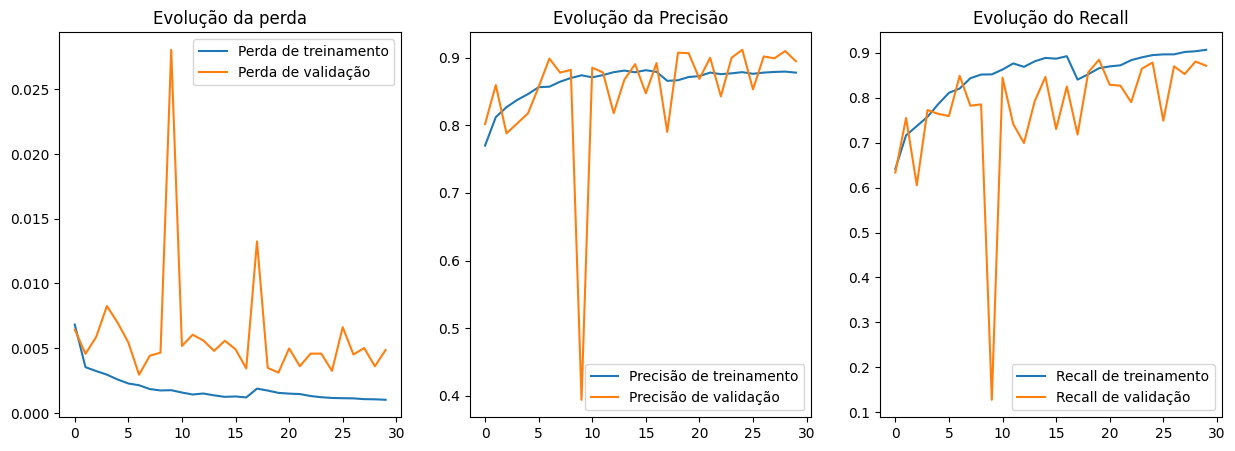

In [14]:

# Visualização da evolução do treinamento
import matplotlib.pyplot as plt

def plot_training_metrics(history_1, history_2):
    combined_history = {
        'loss': history_1.history['loss'] + history_2.history['loss'],
        'val_loss': history_1.history['val_loss'] + history_2.history['val_loss'],
        'accuracy': history_1.history['accuracy'] + history_2.history['accuracy'],
        'val_accuracy': history_1.history['val_accuracy'] + history_2.history['val_accuracy'],
        'precision': history_1.history['precision'] + history_2.history['precision'],
        'val_precision': history_1.history['val_precision'] + history_2.history['val_precision'],
        'recall': history_1.history['recall'] + history_2.history['recall'],
        'val_recall': history_1.history['val_recall'] + history_2.history['val_recall'],
    }

    plt.figure(figsize=(15, 5))
    
    # Perda
    plt.subplot(1, 3, 1)
    plt.plot(combined_history['loss'], label='Perda de treinamento')
    plt.plot(combined_history['val_loss'], label='Perda de validação')
    plt.title('Evolução da perda')
    plt.legend()

    # Precisão
    plt.subplot(1, 3, 2)
    plt.plot(combined_history['accuracy'], label='Precisão de treinamento')
    plt.plot(combined_history['val_accuracy'], label='Precisão de validação')
    plt.title('Evolução da Precisão')
    plt.legend()

    # Recall
    plt.subplot(1, 3, 3)
    plt.plot(combined_history['recall'], label='Recall de treinamento')
    plt.plot(combined_history['val_recall'], label='Recall de validação')
    plt.title('Evolução do Recall')
    plt.legend()

    plt.show()

plot_training_metrics(history_1, history_2)


In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Perda no treinamento')
plt.plot(history.history['val_loss'], label='Perda na validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()


NameError: name 'history' is not defined

In [16]:
import datetime
# Obtenha a data e hora atuais no formato YYYY-MM-DD_HH-MM-SS
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Crie um nome de arquivo com data e hora atuais
model_filename = f'deeplabv3plus_{current_time}.h5'

# Salvar o modelo
model.save(model_filename)

print(f"Modelo salvo como: {model_filename}")

/home/santiago/anaconda3/envs/tf_2_15/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modelo salvo como: deeplabv3plus_2025-03-19_18-59-15.h5


In [ ]:
import json

history_filename = f'history_v2_{current_time}.json'

# Salve o histórico de treinamento como um arquivo JSON
with open(history_filename, 'w') as f:
    json.dump(history.history, f)

print(f"Histórico salvo como: {history_filename}")

In [ ]:
loss, accuracy, iou = model.evaluate(test_dataset)
print(f'Perda na avaliação: {loss}')
print(f'Precisão na avaliação: {accuracy}')
print(f'IoU em avaliação: {iou}')

# 1st RETRAIN

In [ ]:
### ATENÇÃO! REVISAR BLOCOS ANTES DE USAR ###
# Carregar o modelo previamente treinado
model = tf.keras.models.load_model(
    'modelo_segmentacion_2025-01-24_07-13-34.h5', 
    custom_objects={'MeanIoU': tf.keras.metrics.MeanIoU}
)

print("Modelo cargado exitosamente.")
model.summary()

In [ ]:
# Configurar un nuevo optimizador con una tasa de aprendizaje reducida
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',  # Pérdida adecuada para multilabel
              metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=18)])

# Definir el número adicional de épocas
EPOCHS_EXTRA = 25

history = model.fit(
    train_dataset,
    epochs=EPOCHS_EXTRA,
    validation_data=val_dataset,
    verbose=1
)

import datetime
# Obtener la fecha y hora actual en formato YYYY-MM-DD_HH-MM-SS
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Crear el nombre del archivo con la fecha y hora actuales
model_filename = f'modelo_segmentacion_retrained_{current_time}.h5'

# Guardar el modelo
model.save(model_filename)

print(f"Modelo guardado como: {model_filename}")

import json

history_filename = f'history_retrained_{current_time}.json'

# Guardar el historial de entrenamiento como un archivo JSON
with open(history_filename, 'w') as f:
    json.dump(history.history, f)


print(f"Historial guardado como: {history_filename}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Perda no treinamento')
plt.plot(history.history['val_loss'], label='Perda na validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

2025-03-19 18:59:37.071044: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-03-19 18:59:37.071528: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1/1 [==============================] - 1s 1s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07319346..1.0477667].


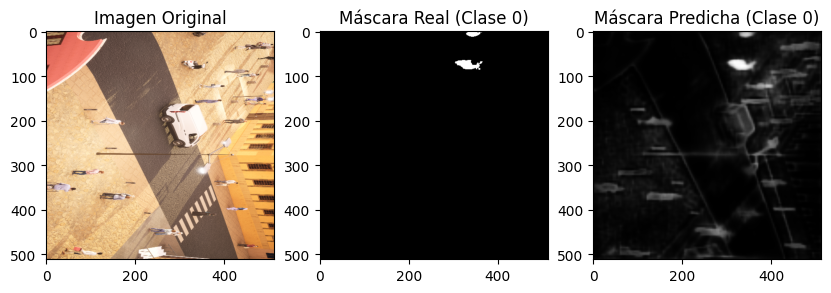

In [17]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]

        plt.figure(figsize=(10, 5))

        # Imagen original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagen Original")

        # Visualizar clase 0 real y predicha
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 16], cmap='gray')
        plt.title("Máscara Real (Clase 0)")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[:, :, 16], cmap='gray')
        plt.title("Máscara Predicha (Clase 0)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)


# 2nd RETRAIN

In [ ]:
# Carregar o modelo previamente treinado
model = tf.keras.models.load_model(
    'modelo_segmentacion_retrained_2025-01-27_06-39-03.h5', 
    custom_objects={'MeanIoU': tf.keras.metrics.MeanIoU}
)

print("Modelo cargado exitosamente.")
model.summary()

In [ ]:
# Configurar un nuevo optimizador con una tasa de aprendizaje reducida
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',  # Pérdida adecuada para multilabel
              metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=18)])

# Definir el número adicional de épocas
EPOCHS_EXTRA = 50

history = model.fit(
    train_dataset,
    epochs=EPOCHS_EXTRA,
    validation_data=val_dataset,
    verbose=1
)

import datetime
# Obtener la fecha y hora actual en formato YYYY-MM-DD_HH-MM-SS
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Crear el nombre del archivo con la fecha y hora actuales
model_filename = f'modelo_segmentacion_retrained_{current_time}.h5'

# Guardar el modelo
model.save(model_filename)

print(f"Modelo guardado como: {model_filename}")

import json

history_filename = f'history_retrained_{current_time}.json'

# Guardar el historial de entrenamiento como un archivo JSON
with open(history_filename, 'w') as f:
    json.dump(history.history, f)


print(f"Historial guardado como: {history_filename}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Perda no treinamento')
plt.plot(history.history['val_loss'], label='Perda na validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

2025-03-19 19:00:16.863420: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-03-19 19:00:16.863585: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1/1 [==============================] - 0s 14ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09136078..0.9015837].


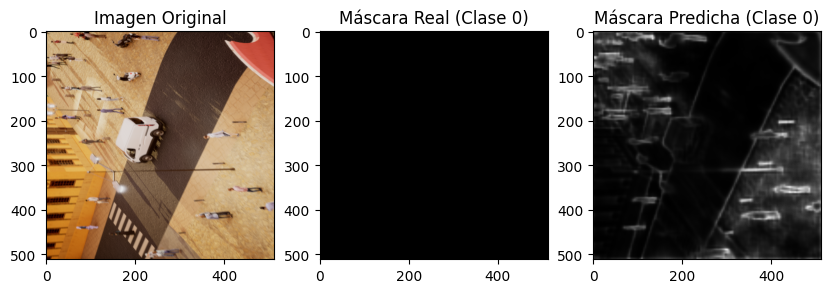

In [18]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]

        plt.figure(figsize=(10, 5))

        # Imagen original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagen Original")

        # Visualizar clase 0 real y predicha
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 2], cmap='gray')
        plt.title("Máscara Real (Clase 0)")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[:, :, 2], cmap='gray')
        plt.title("Máscara Predicha (Clase 0)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)


2025-03-19 19:01:38.131940: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-03-19 19:01:38.132069: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1/1 [==============================] - 0s 15ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.039206535..0.936126].


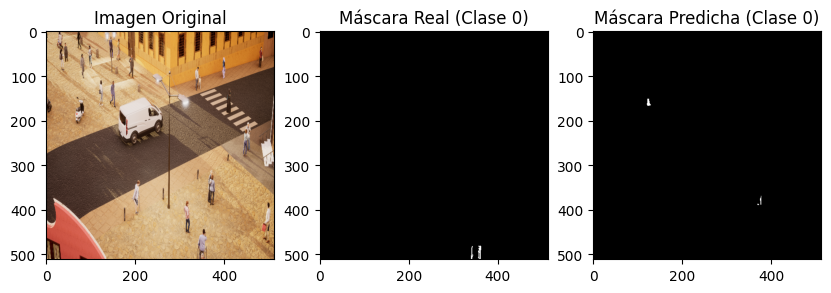

In [21]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]
        binary_pred_mask = (pred_mask >= 0.3).astype(int)  # Umbral de 0.5

        plt.figure(figsize=(10, 5))

        # Imagen original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagen Original")

        # Visualizar clase 0 real y predicha
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 3], cmap='gray')
        plt.title("Máscara Real (Clase 0)")

        plt.subplot(1, 3, 3)
        plt.imshow(binary_pred_mask[:, :, 3], cmap='gray')
        plt.title("Máscara Predicha (Clase 0)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)

1/1 [==============================] - 0s 14ms/step


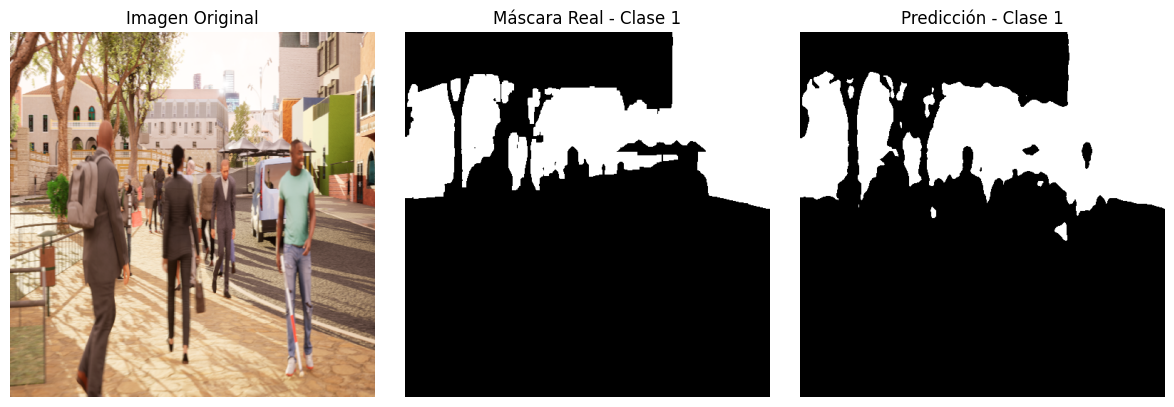

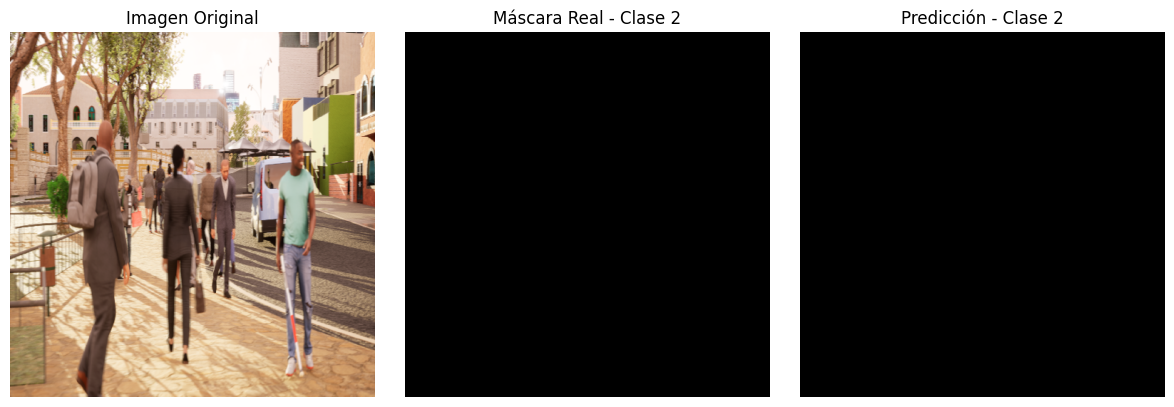

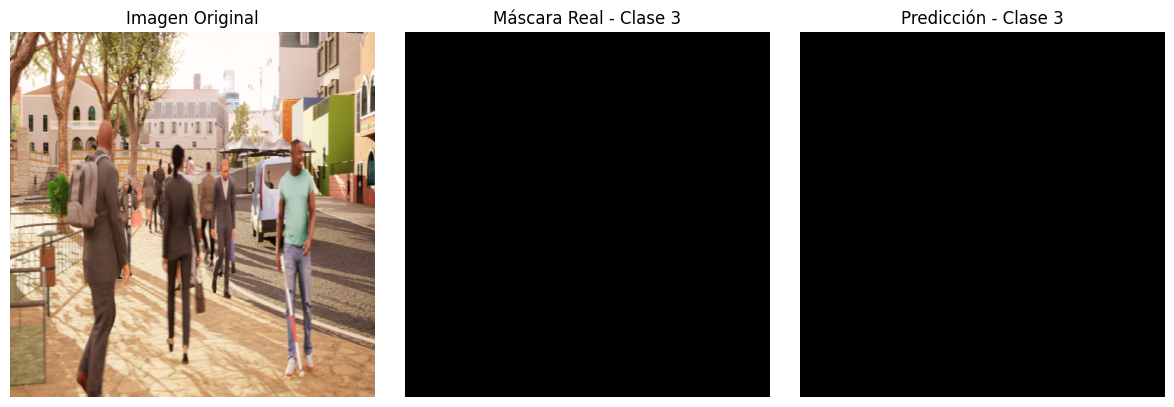

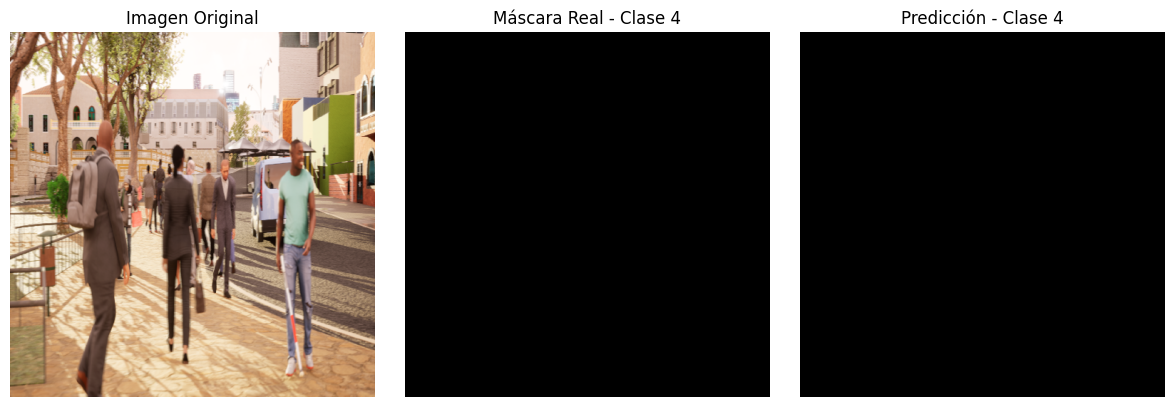

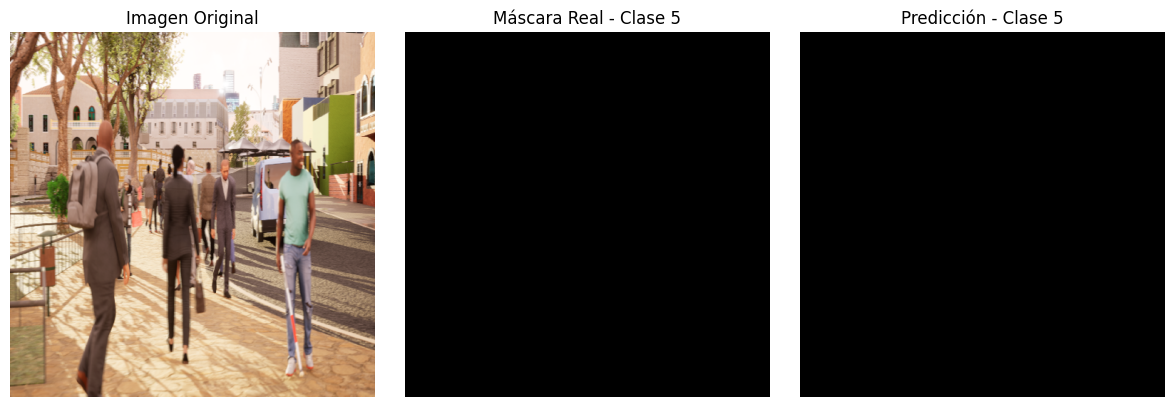

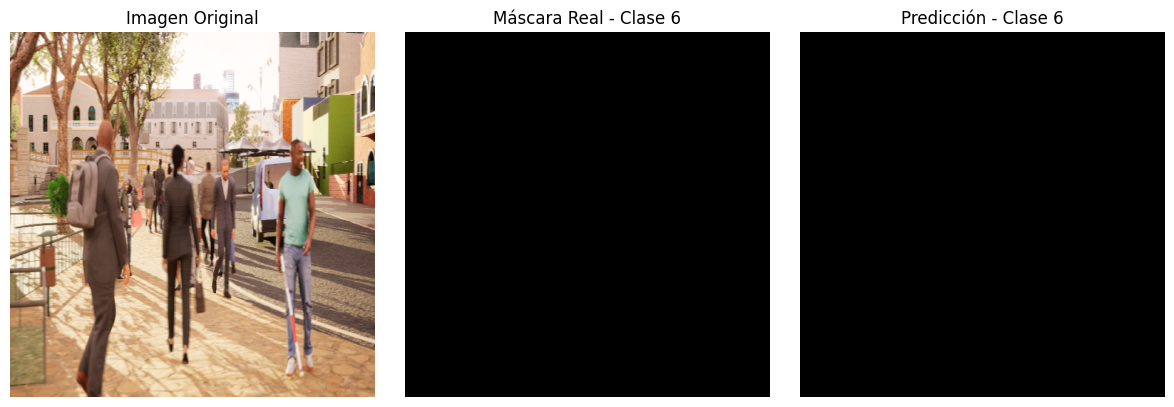

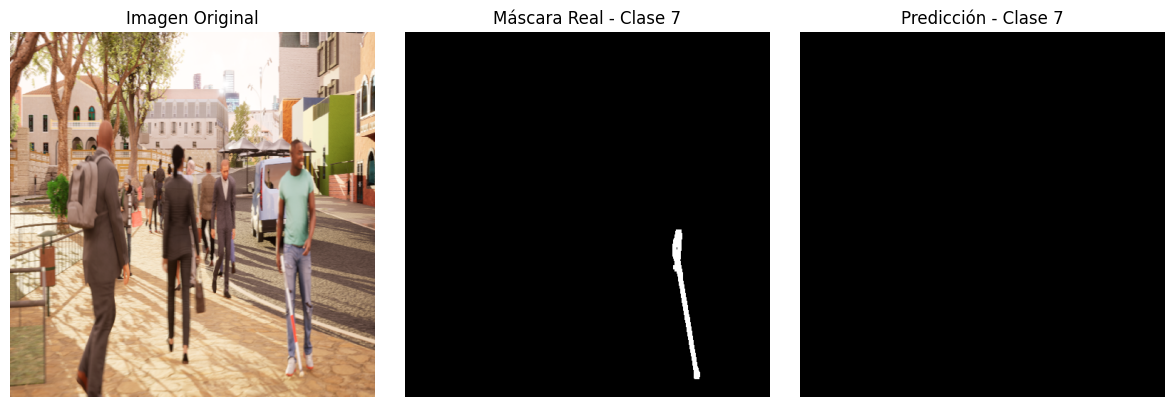

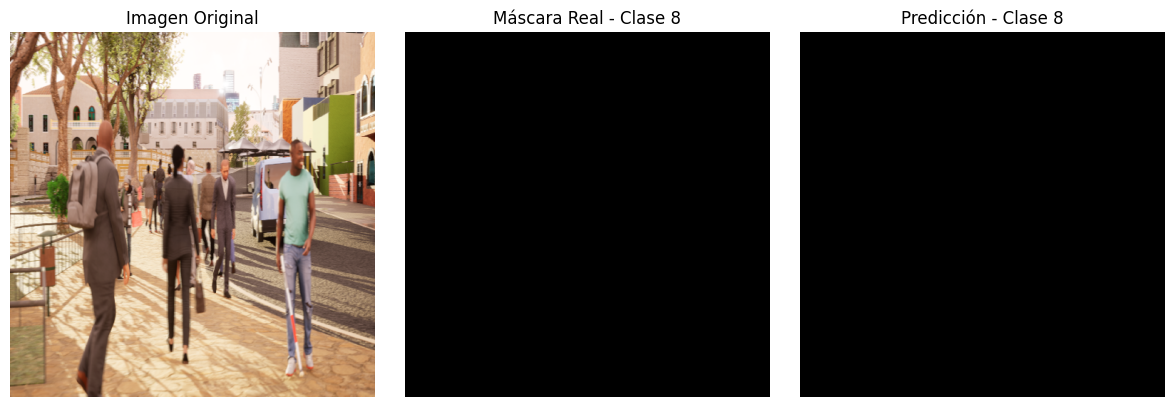

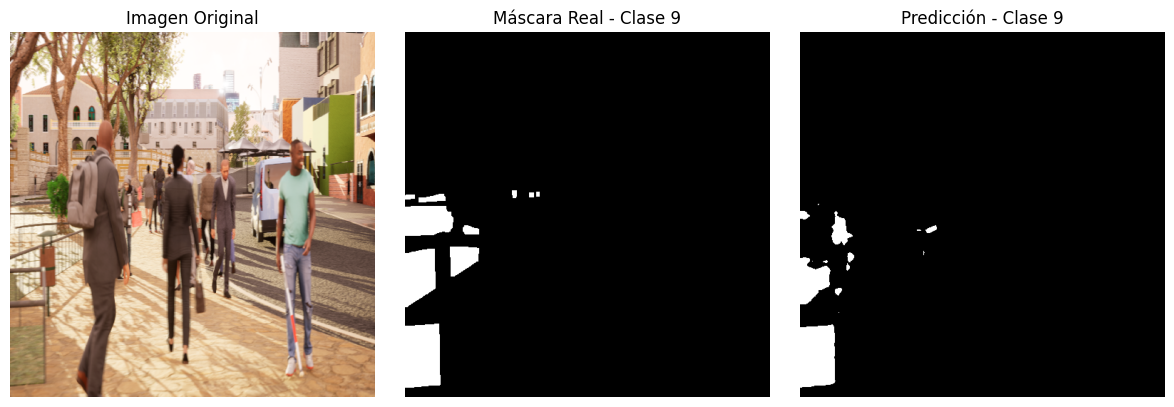

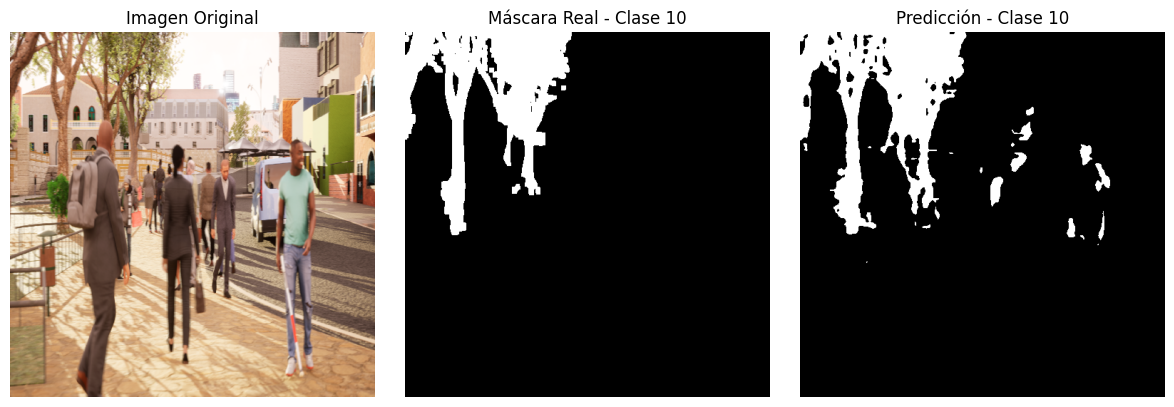

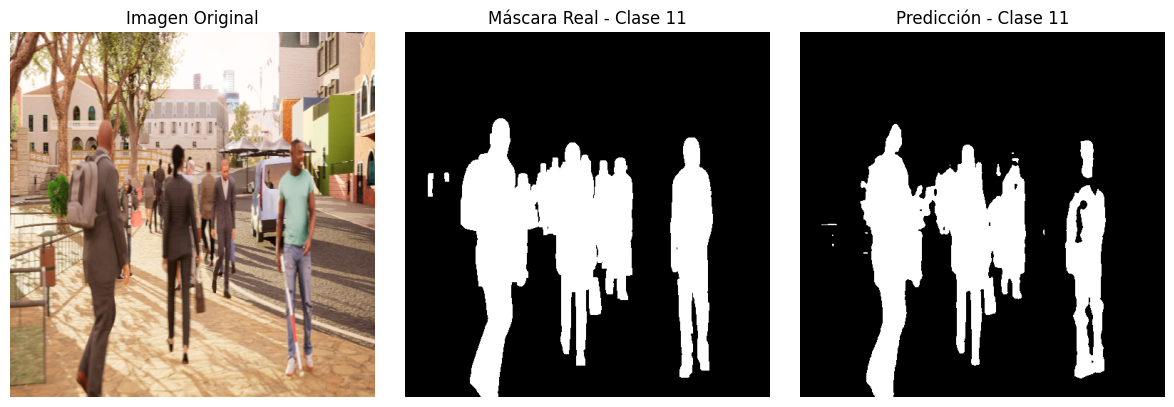

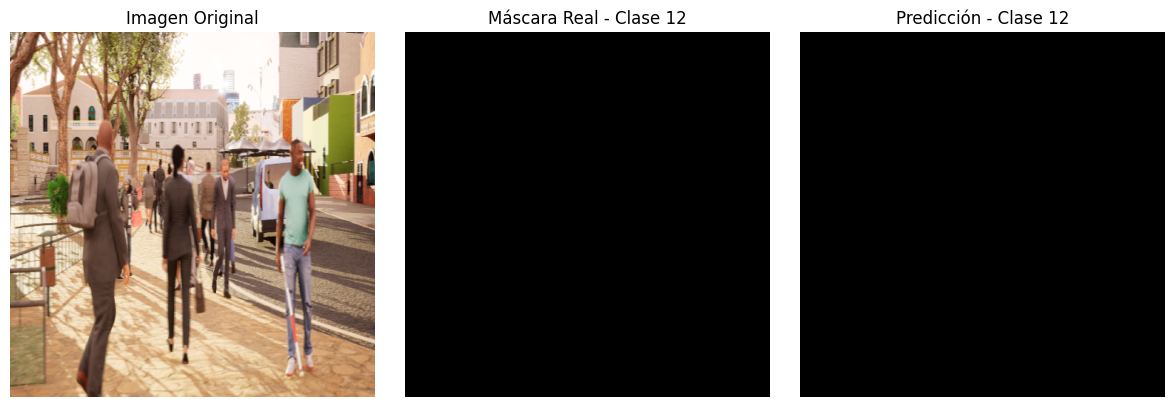

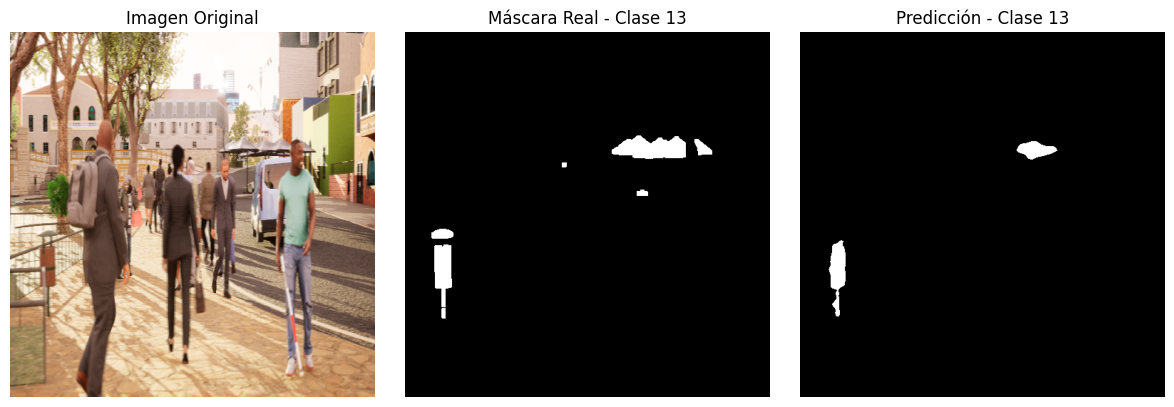

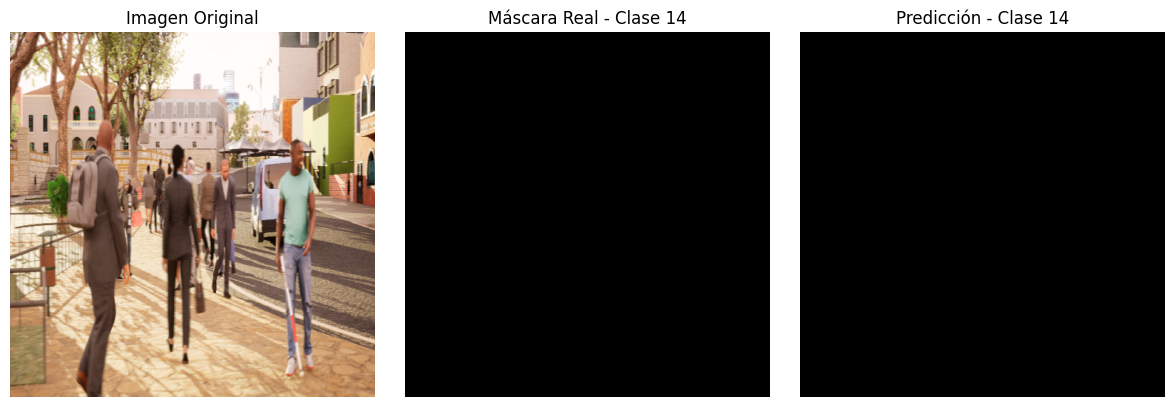

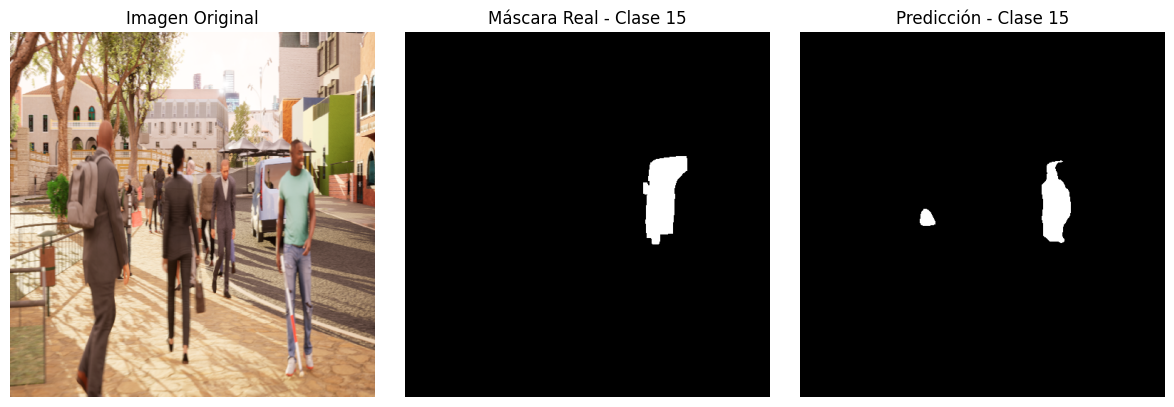

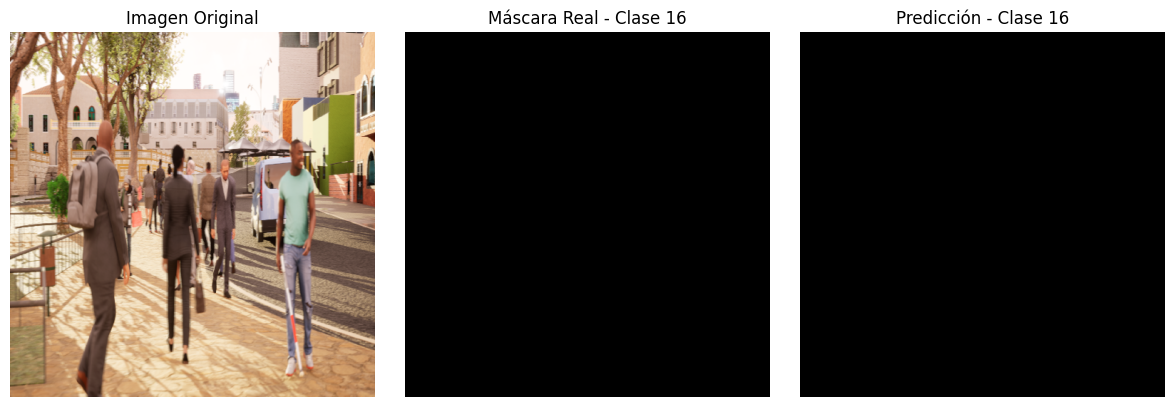

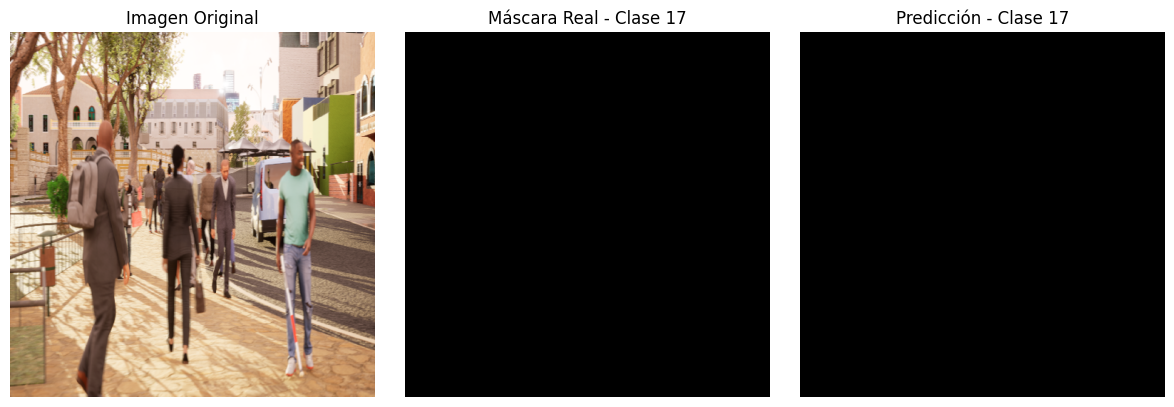

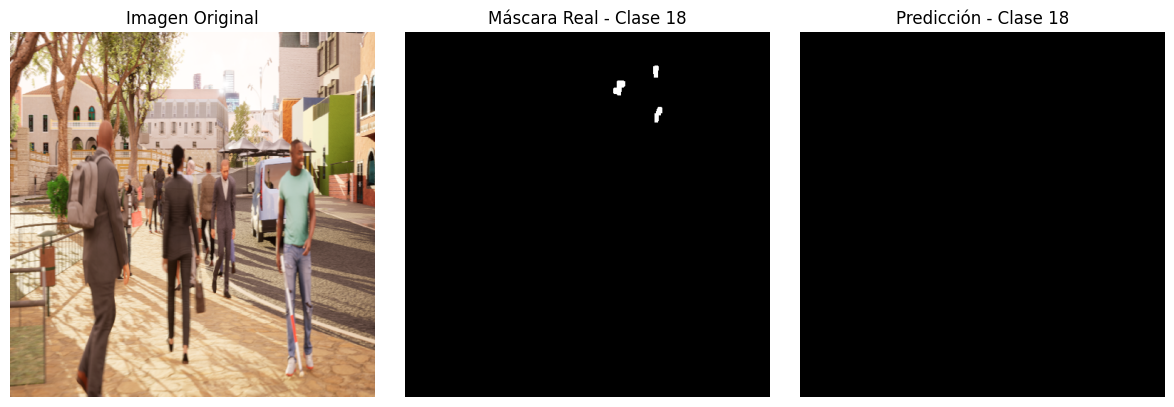

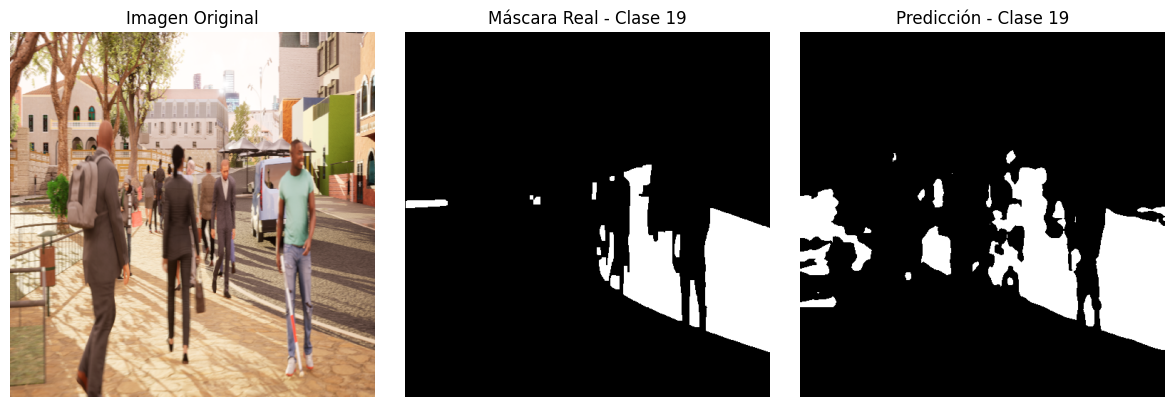

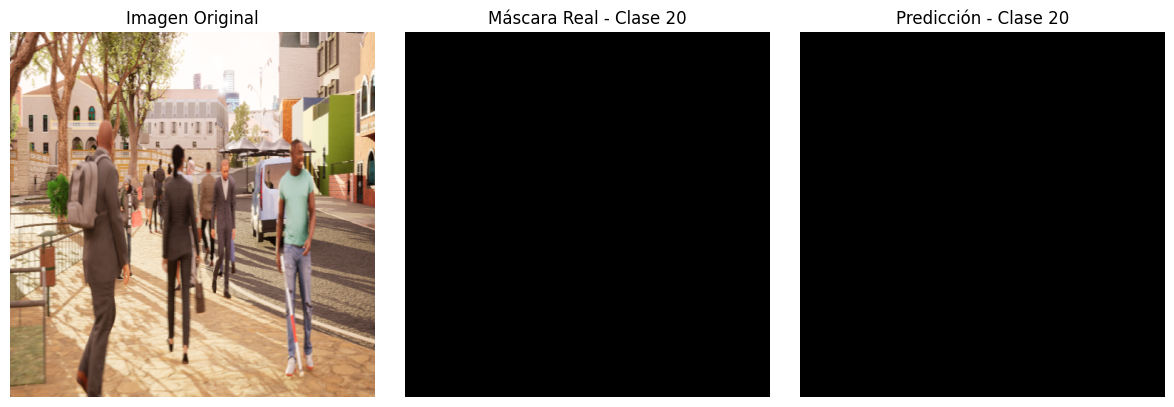

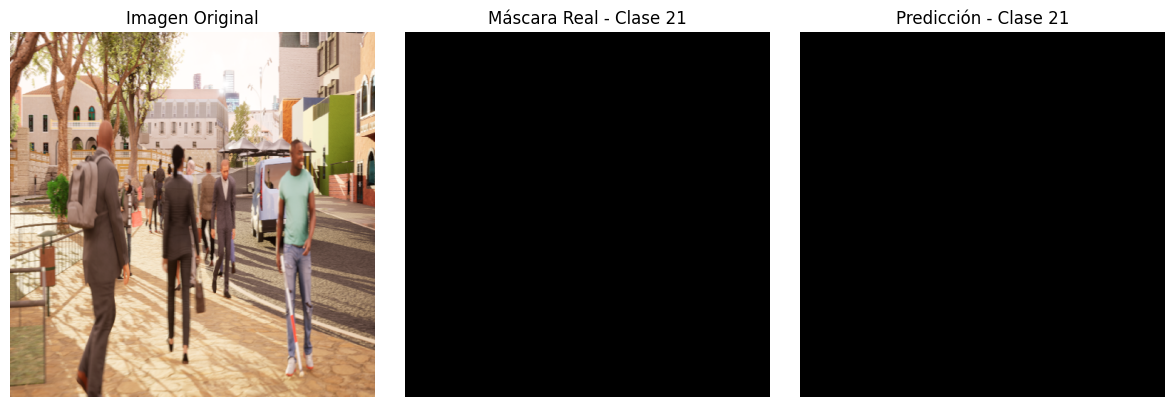

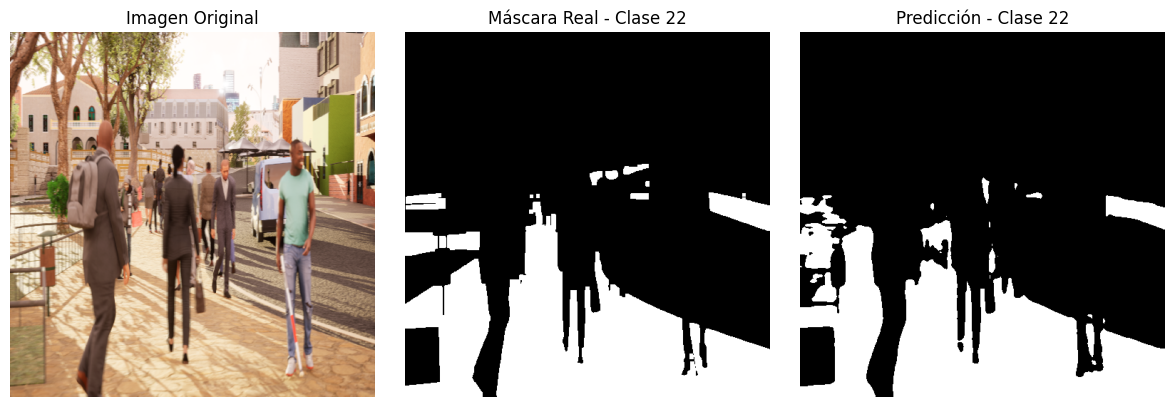

In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2

def predict_and_compare_22_classes(model, image_path, mask_path, threshold=0.3):
    """
    Carga una imagen y su máscara real, realiza predicción y visualiza comparación para 22 clases.

    Args:
        model: El modelo entrenado de segmentación.
        image_path: Ruta de la imagen.
        mask_path: Ruta del archivo .npy con la máscara real.
        threshold: Umbral para binarizar la predicción.
    """
    # Cargar imagen
    img = load_img(image_path, target_size=(512, 512))
    img_array = img_to_array(img) / 255.0
    img_tensor = tf.expand_dims(img_array, axis=0)

    # Cargar máscara real
    real_mask = np.load(mask_path)

    # Predicción
    pred_mask = model.predict(img_tensor)[0]

    # Binarización
    binary_pred_mask = (pred_mask >= threshold).astype(int)

    # Visualización
    for i in range(22):
        plt.figure(figsize=(12, 4))

        # Imagen Original
        plt.subplot(1, 3, 1)
        plt.imshow(img_array)
        plt.title("Imagen Original")
        plt.axis('off')

        # Máscara Real con dilatación
        plt.subplot(1, 3, 2)
        kernel = np.ones((3, 3), np.uint8)
        dilated_real_mask = cv2.dilate(real_mask[:, :, i], kernel, iterations=2)
        plt.imshow(dilated_real_mask, cmap='gray')
        plt.title(f"Máscara Real - Clase {i+1}")
        plt.axis('off')

        # Máscara Predicha
        plt.subplot(1, 3, 3)
        plt.imshow(binary_pred_mask[:, :, i], cmap='gray')
        plt.title(f"Predicción - Clase {i+1}")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Ejemplo de uso:
# model = tf.keras.models.load_model("ruta_a_modelo.h5")
image_path = "/media/santiago/HD710PRO/ImagenesSinteticas/FinalImage/2760.png"
mask_path = "/media/santiago/HD710PRO/ImagenesSinteticas/output/2760.npy"
predict_and_compare_22_classes(model, image_path, mask_path)

1/1 [==============================] - 0s 13ms/step


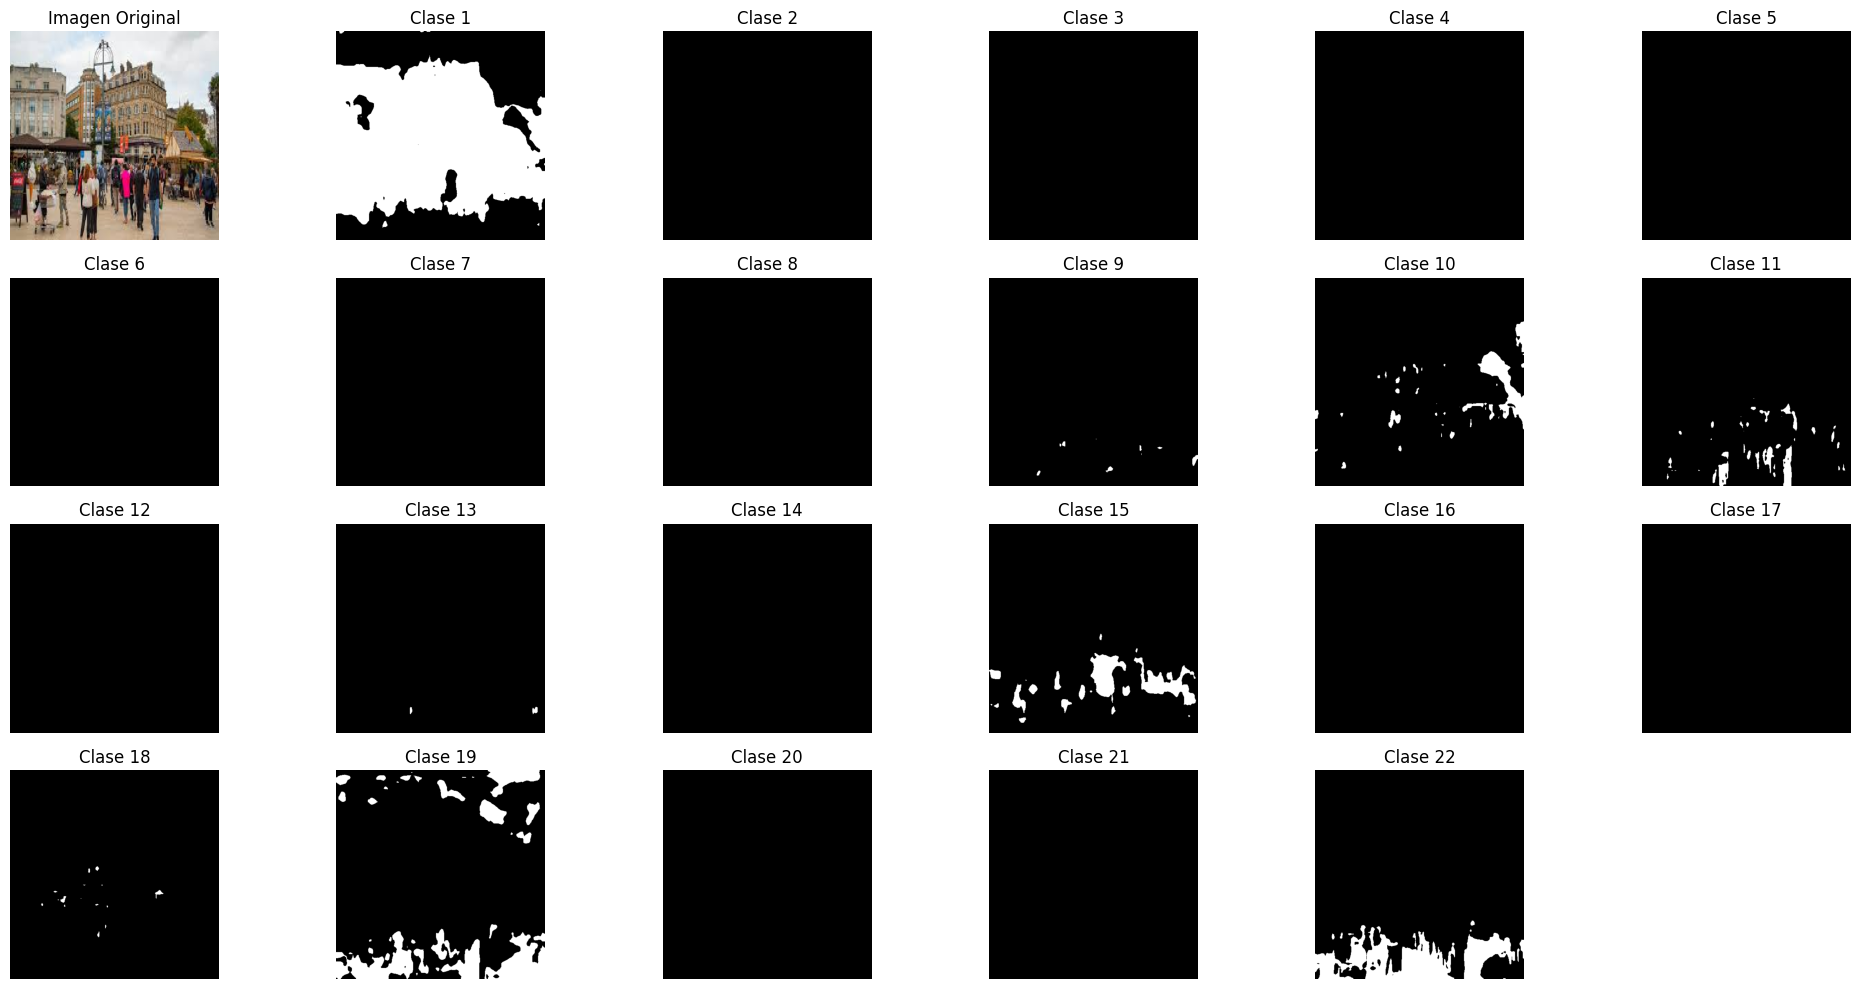

In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_and_visualize_22_classes(model, image_path, threshold=0.3):
    """
    Carga una imagen, realiza la predicción y visualiza las 22 clases en máscaras binarias individuales.

    Args:
        model: Modelo de segmentación entrenado.
        image_path: Ruta a la imagen para predecir.
        threshold: Umbral para binarizar la predicción (default=0.2).
    """
    # Cargar imagen y preprocesar
    img = load_img(image_path, target_size=(512, 512))
    img_array = img_to_array(img) / 255.0
    img_tensor = tf.expand_dims(img_array, axis=0)

    # Predicción
    pred_mask = model.predict(img_tensor)[0]

    # Binarización
    binary_pred_mask = (pred_mask >= threshold).astype(int)

    # Visualizar imagen original
    plt.figure(figsize=(20, 10))
    plt.subplot(4, 6, 1)
    plt.imshow(img_array)
    plt.title("Imagen Original")
    plt.axis('off')

    # Visualizar las 22 máscaras
    for i in range(22):
        plt.subplot(4, 6, i + 2)
        plt.imshow(binary_pred_mask[:, :, i], cmap='gray')
        plt.title(f"Clase {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejemplo de uso
# model = tf.keras.models.load_model("ruta_a_modelo.h5")
image_path = "/home/santiago/Descargas/prueba2.jpeg"
predict_and_visualize_22_classes(model, image_path)